## ANN Regression

In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv(r'E:\Proj\PowerPlant\powerplant_data.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X= df.drop("PE",axis=1)
y= df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
# Data splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

In [10]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [11]:
import torch
import torch.nn as nn

X_train_tensor= torch.tensor(X_train_scaled).float()
y_train_tensor= torch.tensor(y_train.values).float().view(-1,1)

X_test_tensor= torch.tensor(X_test_scaled).float()
y_test_tensor= torch.tensor(y_test.values).float().view(-1,1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## 

## ANN Model

In [14]:
# Building the ANN model

class Powerplant(nn.Module):
    def __init__(self):
        super(Powerplant, self).__init__()    
        self.model = nn.Sequential(
            
            nn.Linear(X_train.shape[1], 6),    # 1st hidden layer
            nn.ReLU(),
            
            nn.Linear(6, 6),                   # 2nd hidden layer
            nn.ReLU(),
            
            nn.Linear(6, 1)                    # Output layer  
    )
    
    def forward(self, x):                      # Forward propagation
        return self.model(x)
    

In [15]:
import torch.optim as optim                   # loss optimizer

model= Powerplant()
criterion = nn.MSELoss()
optimizer= optim.Adam(model.parameters())

In [16]:
train_losses= []
val_losses= []

best_val_loss= float('inf')

num_epochs= 100
for epoch in range(num_epochs):
    model.train()
    
    running_loss= 0.0
    
    for xb, yb in train_loader:       # xb is features of 1 batch
                                      # yb is labels of 1 batch
        optimizer.zero_grad()         # zero the gradients before backward pass
        outputs = model(xb)           # Forward propagation...prediction
        loss= criterion(outputs, yb)  # compute loss
        loss.backward()               # Backpropagation    
        optimizer.step()              # update params
       
        running_loss+= loss.item()
        
    epoch_train_loss= running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation loss
    
    model.eval()
    running_val_loss= 0.0
    with torch.no_grad():
         for xb, yb  in test_loader:
             outputs= model(xb)
             loss= criterion(outputs, yb)
             running_val_loss+= loss
    
    epoch_val_loss= running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss.item())    
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
    
    if  epoch_val_loss.item() < best_val_loss:
        best_val_loss= epoch_val_loss
        torch.save(model.state_dict(), "best_model.pth")

Epoch [1/100], Train Loss: 205485.8186, Val Loss: 203101.3281
Epoch [2/100], Train Loss: 196192.2769, Val Loss: 185134.8438
Epoch [3/100], Train Loss: 165008.1960, Val Loss: 140790.5625
Epoch [4/100], Train Loss: 112018.5910, Val Loss: 83979.8984
Epoch [5/100], Train Loss: 60682.8321, Val Loss: 42337.8281
Epoch [6/100], Train Loss: 32149.8786, Val Loss: 25763.9688
Epoch [7/100], Train Loss: 22671.9982, Val Loss: 20521.5879
Epoch [8/100], Train Loss: 18883.6544, Val Loss: 17284.4727
Epoch [9/100], Train Loss: 15772.9223, Val Loss: 14194.8691
Epoch [10/100], Train Loss: 12722.2617, Val Loss: 11176.1250
Epoch [11/100], Train Loss: 9805.7681, Val Loss: 8379.1504
Epoch [12/100], Train Loss: 7205.5514, Val Loss: 6034.1172
Epoch [13/100], Train Loss: 5121.5576, Val Loss: 4182.7163
Epoch [14/100], Train Loss: 3500.3434, Val Loss: 2804.2419
Epoch [15/100], Train Loss: 2333.5718, Val Loss: 1857.2550
Epoch [16/100], Train Loss: 1546.6497, Val Loss: 1235.4764
Epoch [17/100], Train Loss: 1028.1661,

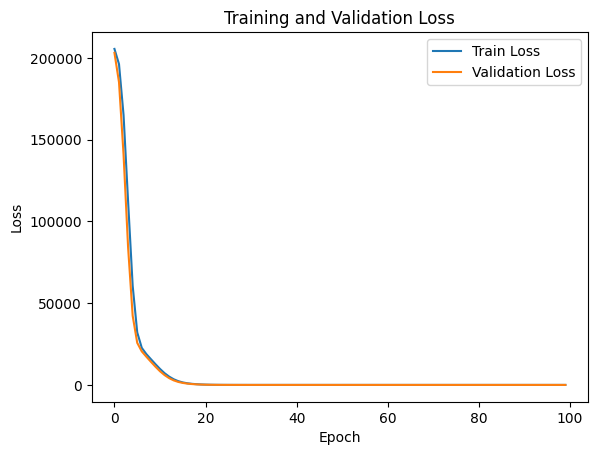

In [17]:
import matplotlib.pyplot as plt
lossdf= pd.DataFrame({"Train Loss": train_losses, 
              "Validation Loss": val_losses})

plt.plot(lossdf["Train Loss"], label="Train Loss")
plt.plot(lossdf["Validation Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [18]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pth"))

C:\Users\VEDANT\AppData\Local\Temp\ipykernel_23212\2785742667.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


<All keys matched successfully>

In [19]:
# Evaluating the model

model.eval()
with torch.no_grad():
    train_pred= model(X_train_tensor)
    test_pred= model(X_test_tensor)
    
    train_mse= criterion(train_pred, y_train_tensor)
    test_mse= criterion(test_pred, y_test_tensor)
    
print(f"Train MSE: {train_mse.item():.4f}, Test MSE: {test_mse.item():.4f}")

Train MSE: 20.8427, Test MSE: 19.1459


In [20]:
from sklearn.metrics import r2_score

print("R2 score", r2_score(y_test, test_pred))

R2 score 0.9330901146226303
